# Individual Project Planning Stage 
Ray Wu - 57494734
<br>Link to Github Repository: https://github.com/raywu255/Project-Planning-Stage-Individual- 

In [1]:
library(tidyverse)
library(GGally)
library(repr)
library(tidymodels)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2

── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── t

## Broad Question: Can the variables: Age, Playtime and Session Frequency be used to predict whether a user will subscribe to the newsletter, and how do these variables vary across the different experience level classifications (Amateur, Regular, Pro, Veteran) and gender?

### Data Description

In [33]:
#Reading datasets
player_data <- read_csv("players.csv") |>
    mutate(experience = as.factor(experience)) |>
    mutate(gender = as.factor(gender))
    
session_data <- read_csv("sessions.csv") |>
    separate(col = start_time, into = c("start_date", "start_time"), sep = " ") |>
    separate(col = end_time, into = c("end_date", "end_time"), sep = " ")

game_data <- left_join(player_data, session_data)
game_data

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Joining with `by = join_by(hashedEmail)`


experience,subscribe,hashedEmail,played_hours,name,gender,Age,start_date,start_time,end_date,end_time,original_start_time,original_end_time
<fct>,<lgl>,<chr>,<dbl>,<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,08/08/2024,00:21,08/08/2024,01:35,1.72308e+12,1.72308e+12
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,09/09/2024,22:30,09/09/2024,22:37,1.72592e+12,1.72592e+12
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,08/08/2024,02:41,08/08/2024,03:25,1.72308e+12,1.72309e+12
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,10/09/2024,15:07,10/09/2024,15:29,1.72598e+12,1.72598e+12
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,05/05/2024,22:21,05/05/2024,23:17,1.71495e+12,1.71495e+12
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,06/04/2024,22:24,06/04/2024,23:33,1.71244e+12,1.71245e+12
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,20/04/2024,20:46,20/04/2024,21:48,1.71365e+12,1.71365e+12
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,15/06/2024,16:37,15/06/2024,18:37,1.71847e+12,1.71848e+12
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,05/05/2024,23:40,06/05/2024,00:55,1.71495e+12,1.71496e+12


In [26]:
#Basic summary statistics
num_sub <- player_data |>
    filter(subscribe == TRUE) |>
    nrow()

num_not_sub <- player_data |>
    filter(subscribe == FALSE) |>
    nrow()

percent_sub <- (num_sub / nrow(player_data))*100

player_data_stat <- player_data |>
    summarize(mean(played_hours, na.rm = TRUE), mean(Age, na.rm = TRUE)) |>
    bind_cols(nrow(player_data), nrow(session_data), num_sub, num_not_sub, percent_sub)
player_data_stat

colnames(player_data_stat) <- c("mean_hrs_played","mean_age", 
                                "player_data_obsv", "session_data_obsv", "num_sub", "num_not_sub", "prcnt_sub")

gender <- player_data |>
    group_by(gender) |>
    summarize(n = n())
gender

exp <- player_data |>
    group_by(experience) |>
    summarize(n = n())
exp

session_num <- game_data |>
    group_by(name) |>
    summarize(n = n())

session <- player_data |>
    select(subscribe, experience) |>
    bind_cols(session_num)


New names:
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`


"mean(played_hours, na.rm = TRUE)","mean(Age, na.rm = TRUE)",...3,...4,...5,...6,...7
<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>
5.845918,21.13918,196,1535,144,52,73.46939


gender,n
<fct>,<int>
Agender,2
Female,37
Male,124
Non-binary,15
Other,1
Prefer not to say,11
Two-Spirited,6


experience,n
<fct>,<int>
Amateur,63
Beginner,35
Pro,14
Regular,36
Veteran,48


**Variable Description**

- experience: categorical variable that describes the experience level of a user.
- subscribe: logical variable that describes whether that user is subscribed to the newsletter (TRUE) or not (FALSE).
- hashedEmail: encrypted email of the user.
- played_hours: the total number of hours the user has on the MineCraft server.
- name: name of the user
- gender: categorical variable describing the gender of the user
- Age: numerical variable describinig the age of the user.
- start_date and end_date: character variables describing when a session started, and ended in DD/MM/YYYY format.
- start_time and end_time: character variables describing the time when the session was started and ended in Hours:Minutes format.
- original_start_time and original_end_time: numerical variables describing session start and end time in Unix time.
  
**Data Wrangling**
Firstly, the player datasets were already in a tidy format, and the experience and gender varibles were changed from <chr> to <fct> datatypes, as they were categorical. Additionally, the sessions dataset was tidied by separating the date and time from start_time and end_time to four new columns, start_date, start_time, end_date, end_time. Finally, these two datasets were combined using left_join.

From the basic statistical summaries, we can see:
- Mean total hours played: 5.85hrs
- Mean age of users: 21
- Number of observations in player_data: 196
- Number of observations in session_data: 1535
- Number of subscribed users: 144
- Number of non-subscribed users: 52
- Percentage of subscribed users: 73.47%

Potential issues with the dataset:
As the majority of users are male, and other genders are underrepresented, it may be difficult to see how results differ across genders, for example, two-spirited, agender and other gendered people have less than 10 users combined. Another issue with the dataset is that the session data has session time in an unfamiliar format, and requires research on new methods to transform the data into a usable/more familiar form.

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_count()`).”


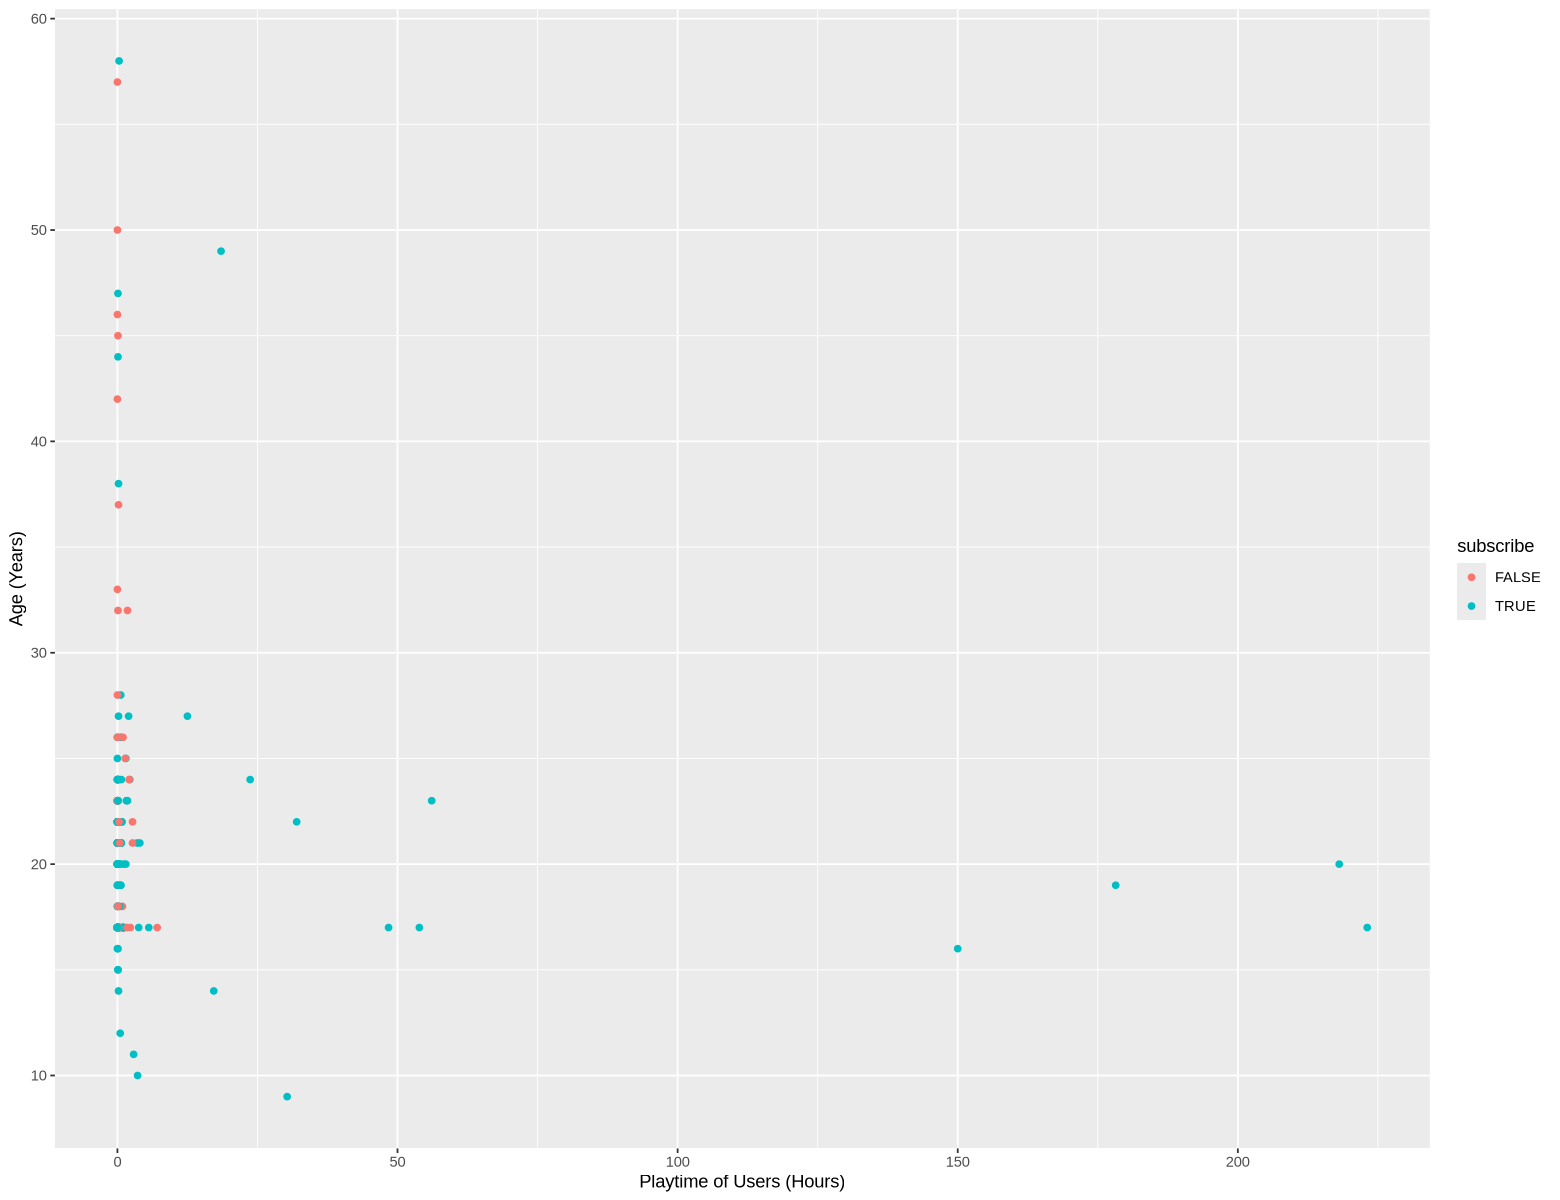

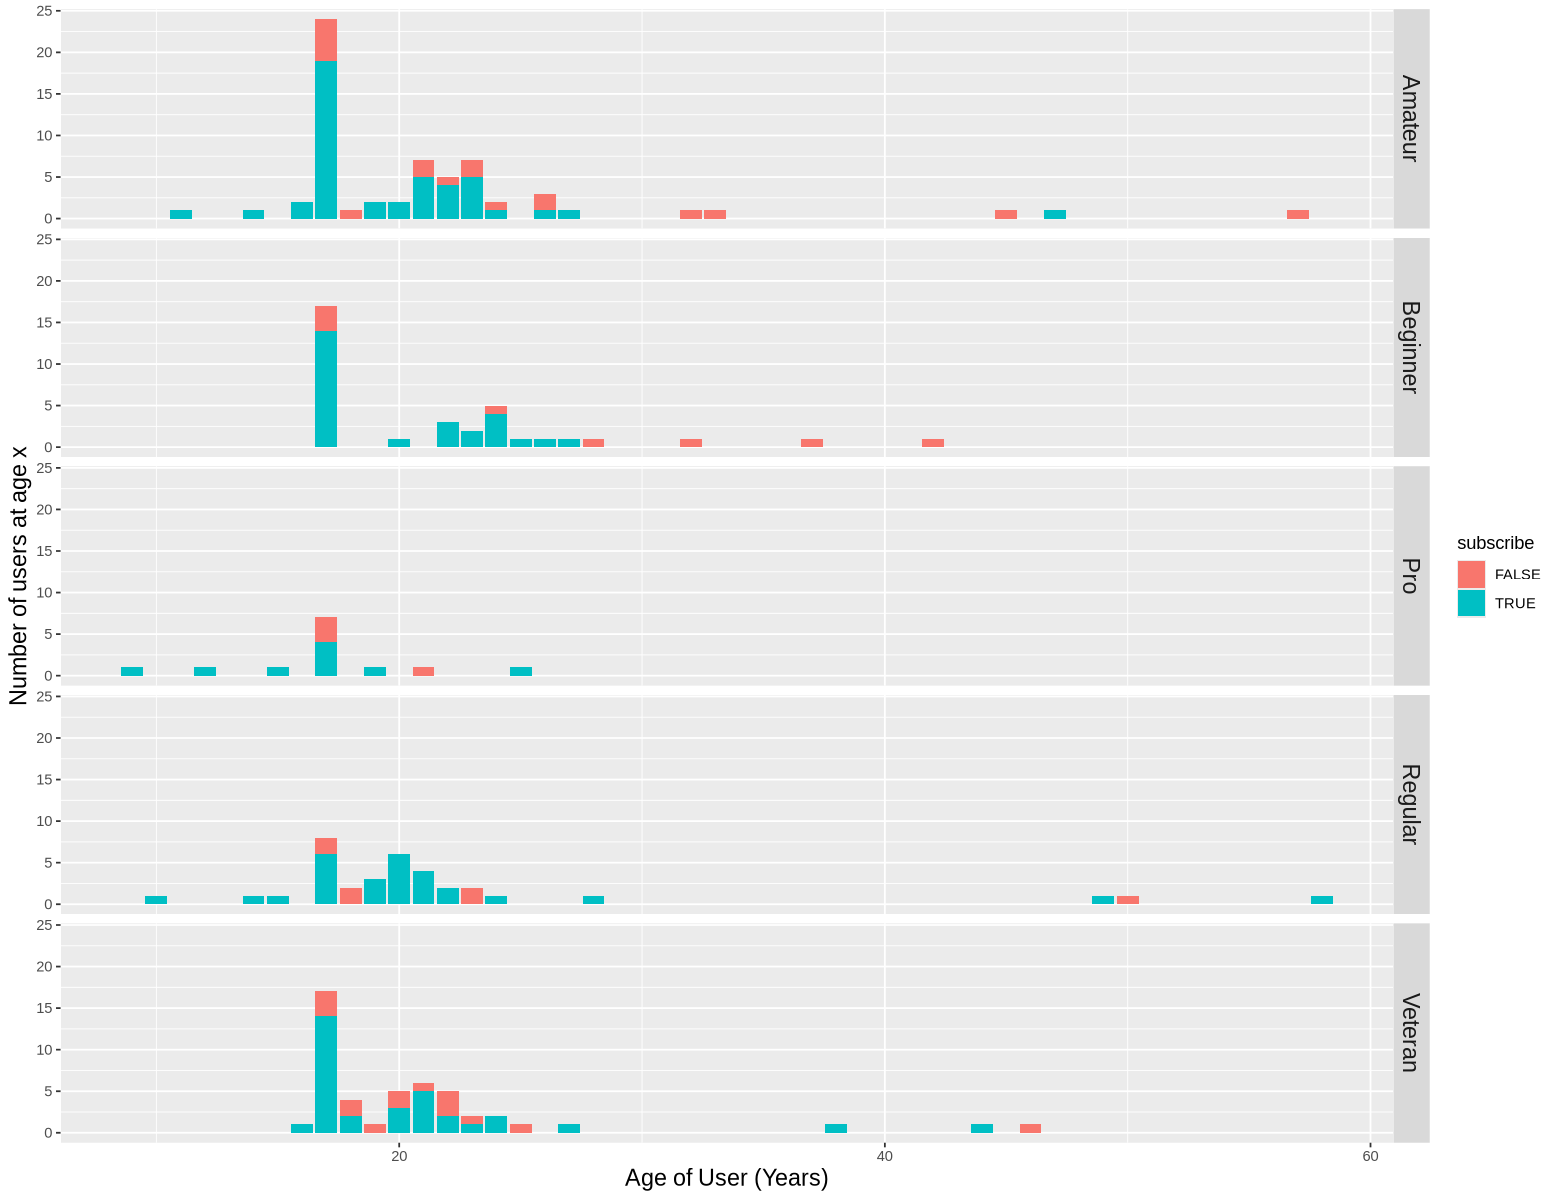

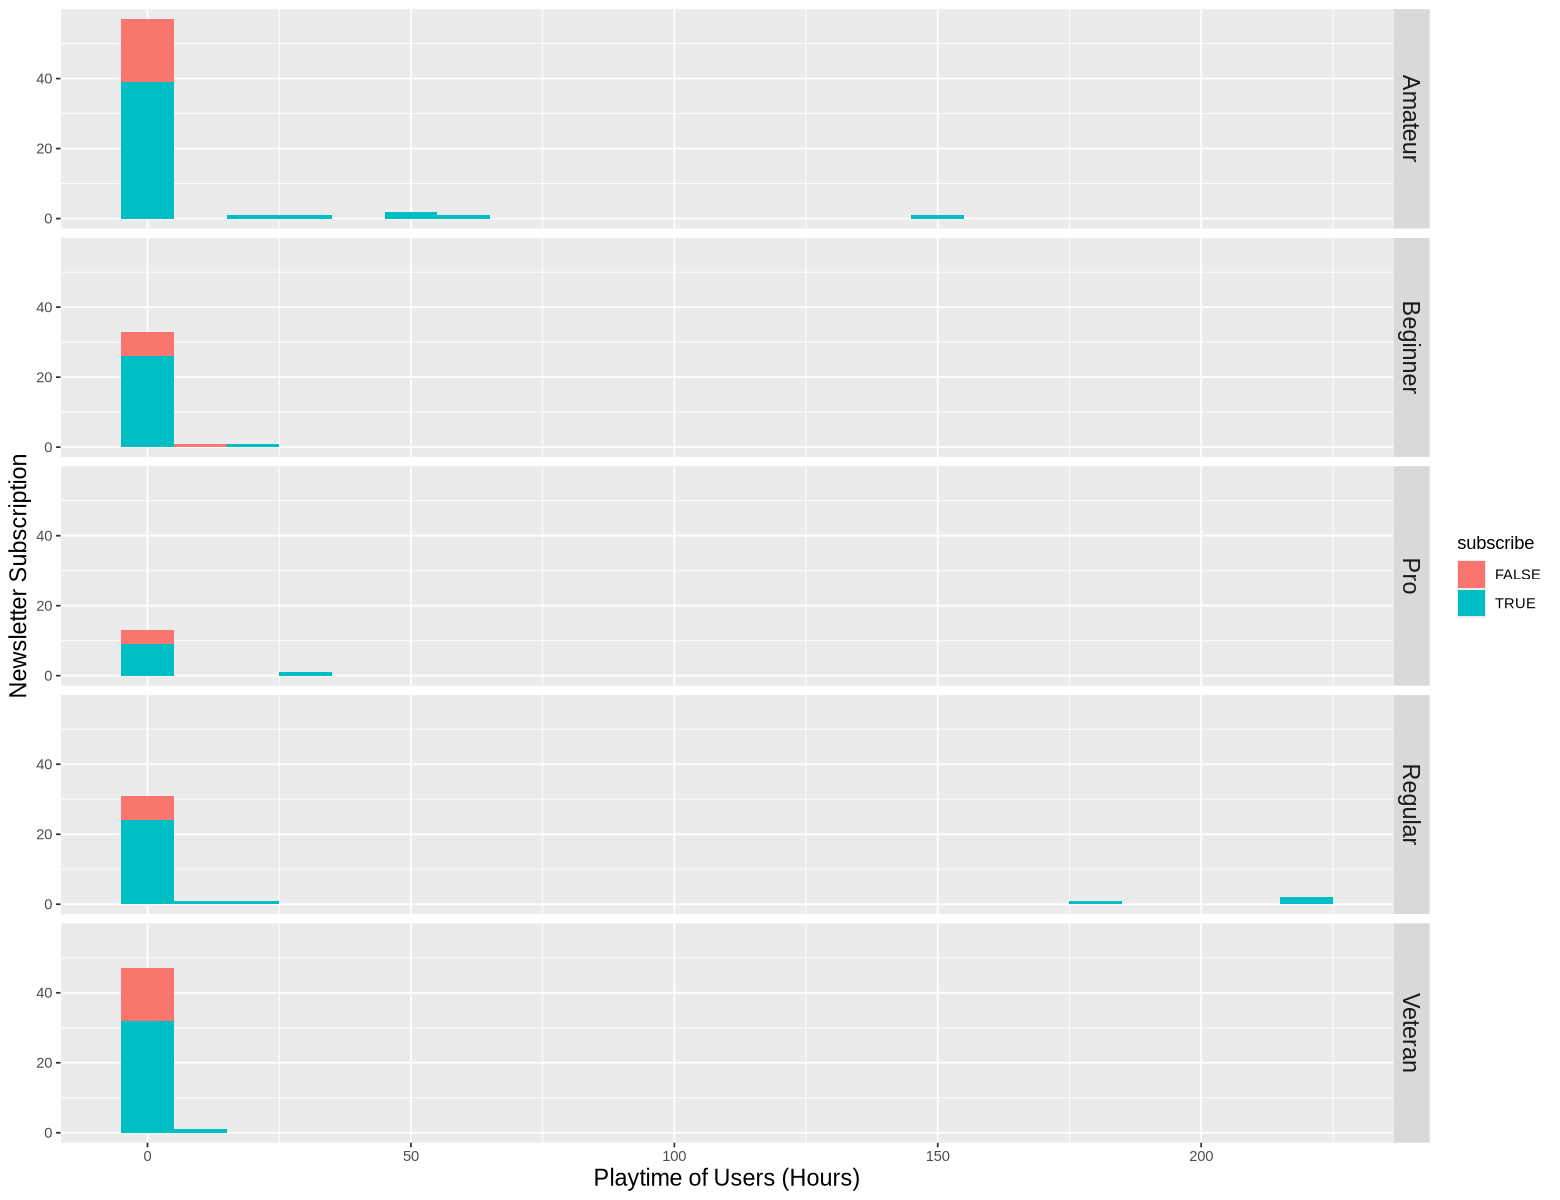

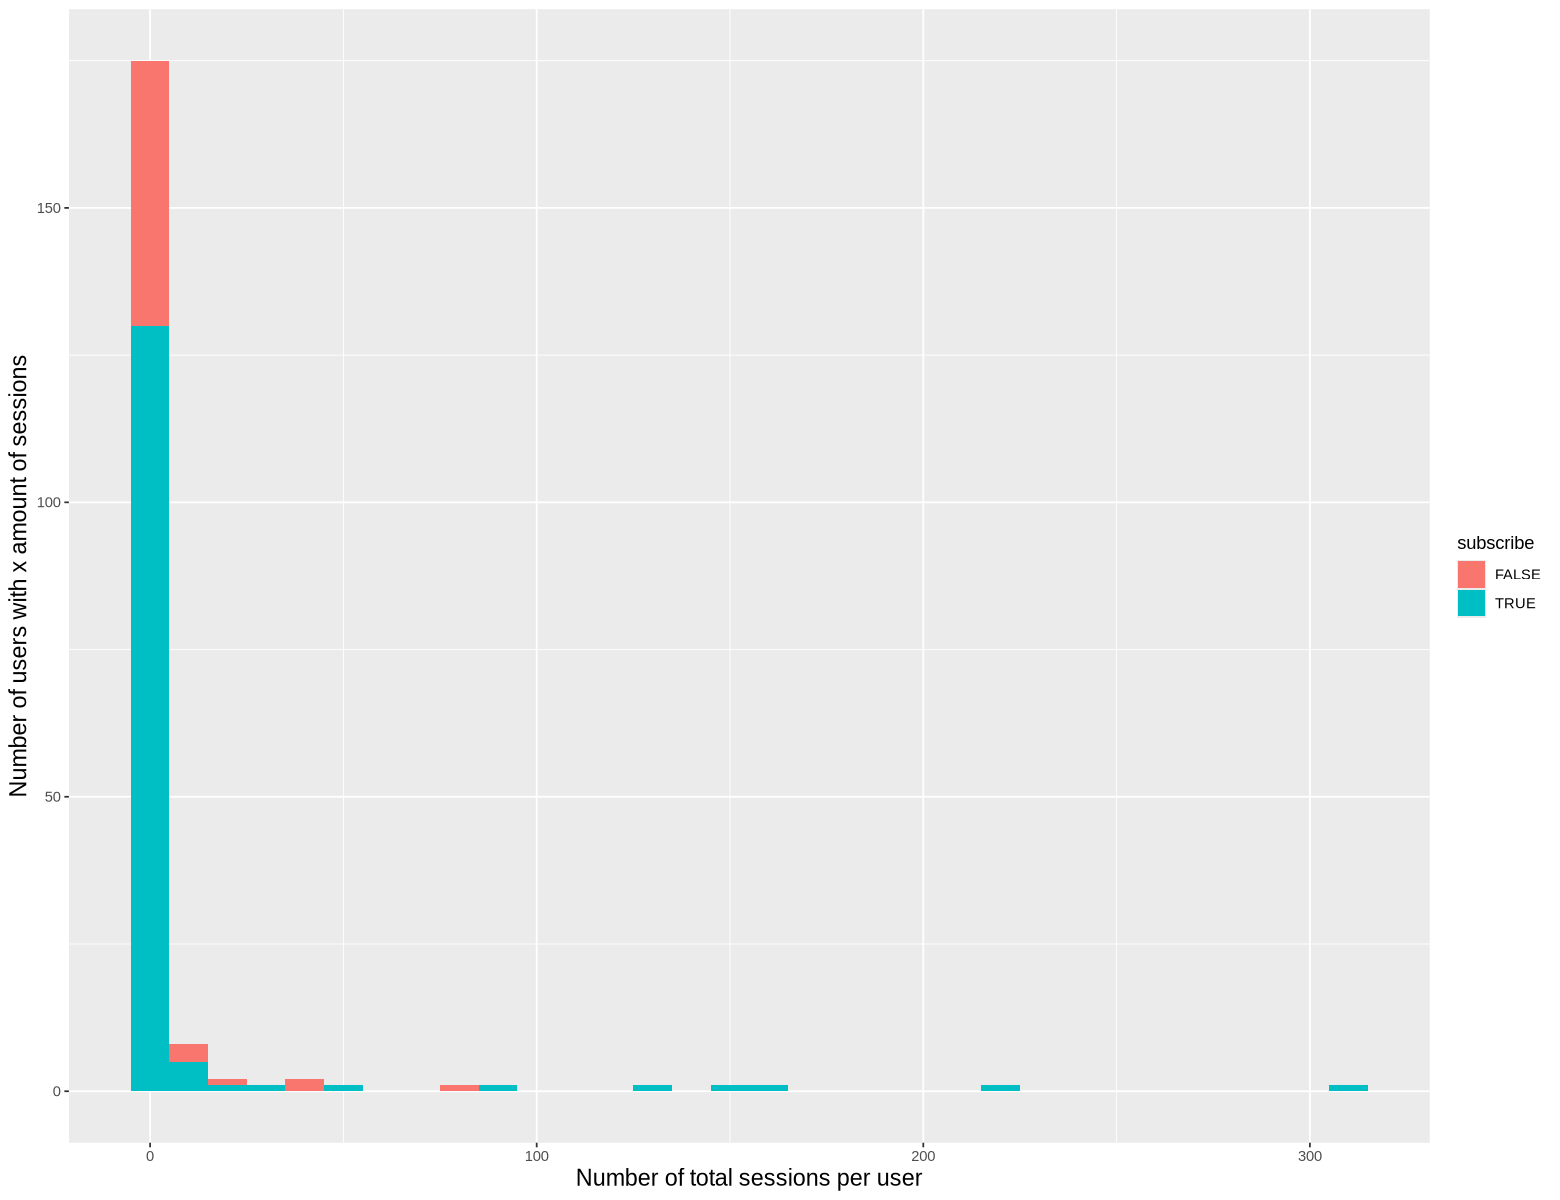

In [30]:
options(repr.plot.width = 13)
options(repr.plot.height = 10)
age_plot <- player_data |>
    ggplot(aes(x=Age, fill = subscribe)) +
    geom_bar() +
    facet_grid(rows = vars(experience)) +
    labs(x="Age of User (Years)", y="Number of users at age x", color = "Subcription Status") + 
    theme(strip.text = element_text(size = 14),
         axis.title = element_text(size = 14))

playtime_plot <- player_data |>
    ggplot(aes(x=played_hours, fill = subscribe)) +
    geom_histogram(binwidth=10) +
    facet_grid(rows = vars(experience)) +
    labs(x="Playtime of Users (Hours)", y="Newsletter Subscription") + 
    theme(strip.text = element_text(size = 14),
         axis.title = element_text(size = 14))

session_plot <- session |>
    ggplot(aes(x=n, fill = subscribe)) +
    geom_histogram(binwidth=10) +
    labs(x="Number of total sessions per user", y="Number of users with x amount of sessions", color = "Subcription Status") + 
    theme(strip.text = element_text(size = 14),
         axis.title = element_text(size = 14))

scatter <- player_data |>
    ggplot(aes(x=played_hours,y = Age, color = subscribe)) + 
    geom_point() + 
    labs(x="Playtime of Users (Hours)", y="Age (Years)")

scatter
age_plot
playtime_plot
session_plot

**Graph Analysis**

From the scatter plot, it is seen that all player who have a playtime of over ~25 hours are subscribed to the newsletter, which means age might be a good predictor of subscription status. Additionally, there is enough data density for KNN classification to work properly. However, around the 0 hours playtime mark, the clusters of subscribed and non-subscribed users are relatively mixed, suggesting either another predictor should be used, or that Age will not be an effective predictor.

From the age histograms, there are multiple trends we can notice. First of all, for all experience levels, the player base is around 20 years old, with the mode age being around 16 years old. From all 5 facets, it is seen that there are players of all experienced levels who have subscribed to the newsletter. Furthermore, across all experience levels, there is a greater amount of subscribed users than non-subscribed users, suggesting that from a visual standpoint, experience level does not have a large influence on whether a not a user will subscribe. This however, requires further numerical analysis. On another note, differences in experience level does not appear to a have a strong correlation to age, as all experience levels have relatively similar "clusters" of age, which hover around 20years old. Finally, the youngest players are in the amateur, pro and regular experience levels, whereas the oldest players are amateurs and regulars as well, likely due to these two experience levels being the most common.

Moving on to the playtime plot, it is that across all experience levels, the majority of players sit within the 0-10 hours bin. Moreover, all "beginner" and "pro" players have less than 40 hours of total playtime, and the groups with the highest playtime are regulars and amateurs, which was unexpected, as you would expect experience with the game to correlate with playtime. On another note, judging from the 0-10 hour bins alone, it is visually seen that beginners have the highest proportion of subscribers to non-subscribers. Similarly, pros and veterans have the lowest proportions, with roughly 60% subcribed to 40% unsubscribed. This highlights potential to use experience levels as a predictor for whether or not a player will subscribed to the newsletter or not.

Finally from the session polot, it is seen that the majority of users of all experience levels have 0-10 total play sessions. Moreover, all users with over 100 sessions are subscribed to the newsletter, indicating possibility for session number to be used as a predictor. However, due to the majority of players having only 1 session, with a quater of those users being non-subscribed, it may be difficult to use session number as a predictor for predicting users with low session numbers.

**Method**

To answer the research question, KNN-Classification can be used.

In your explanation, respond to the following questions:

**Why is this method appropriate?**

This method is appropriate because it works with multiple predictors, such as age, session frequency and total playtime. Additionally, KNN work efficiently and effectively with small datasets, which can be useful once the dataset is disaggregated based on experience level, or gender.

**Which assumptions are required, if any, to apply the method selected?**

For KNN classification to work as intended, there are minimal assumptions regarding what the data looks like. However, it does assume that the data is numerical and scaled to allow for distance calculations.

**What are the potential limitations or weaknesses of the method selected?**

A potential weakness of using KNN classification is that it can be sensitive to outlier data, particularly since the majority of data for the played_hours variable hover around 10hours, players with extremely high playtimes can affect predictive results. Another potential weakness of KNN classification is that it becomes very slow with larger datasets; however, the dataset we're using is relatively small so this shouldn't be an issue.

**How are you going to compare and select the model?**

To compare and select the model with the best parameters, multiple models can be built and their metrics analyzed. In particular, their accuracy and recall of the model should be prioritized due to the goal being to find as many potential subscribers as possible. Therefore, the model with the highest accuracy and recall will be selected.

**How are you going to process the data to apply the model? For example: Are you splitting the data? How? How many splits? What proportions will you use for the splits? At what stage will you split? Will there be a validation set? Will you use cross validation?**

To process the data, all predictors should be standardized (mean of 0 and a standard deviation of 1) to allow all predictor variables to contribute equally towards a distanec  calculation. Additionally, the data will be split 60/40, with 60% to the training data and 40% to the testing data; this maximizes the amount of training data, while also ensuring there is enough data to evaluate the model's performance. In total, there should be two total split, an initial split which divides the dataset into 60/40, and another split to divide the training set 60/40 to create a sub-training set and a validation set to select parameters. Finally, cross validation should also be used to minimize the chance of a "bad split," this is especially important with a small dataset.
